In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import arma_generate_sample

In [2]:
from google.colab import files
upload = files.upload()

Saving AAPL.csv to AAPL.csv
Saving EURUSD.csv to EURUSD.csv
Saving GBPUSD.csv to GBPUSD.csv
Saving SPY.csv to SPY.csv
Saving VIX.csv to VIX.csv


In [3]:
def tsplot(y, lags=None, figsize=(15, 10), style='bmh', title='Graficos para Análisis de Series Temporales'):
    '''Esta función muestra el gráfico de la serie y de las funciones ACF y PACF.'''

    # Verifica si y es una Serie de pandas, si no, la convierte
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    # Configura el estilo del gráfico
    with plt.style.context(style):
        # Crea una figura con el tamaño especificado
        fig = plt.figure(figsize=figsize)

        # Configura la disposición de los subgráficos
        layout = (2, 2)

        # Subgráfico para la serie temporal
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)

        # Subgráfico para la ACF
        acf_ax = plt.subplot2grid(layout, (1, 0))

        # Subgráfico para la PACF
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        # Grafica la serie temporal en el primer subgráfico
        y.plot(ax=ts_ax)
        ts_ax.set_ylabel(r'$y_t$')
        ts_ax.set_xlabel(r'$t$')
        ts_ax.set_title(title)

        # Grafica la ACF en el segundo subgráfico
        sm.graphics.tsa.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)

        # Grafica la PACF en el tercer subgráfico
        sm.graphics.tsa.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)

        # Ajusta el diseño del gráfico
        plt.tight_layout()

    # Retorna, no hay valor de retorno explícito, pero la figura se mostrará si la función se llama desde un entorno interactivo
    return


Esta función, sirve para generar un gráfico de una serie temporal junto con sus funciones de autocorrelación (ACF) y autocorrelación parcial (PACF). Toma una serie temporal, la grafica junto con su ACF y PACF, y muestra el resultado en un gráfico con tres subgráficos.

La función es útil para realizar un análisis visual de la serie temporal y sus patrones de autocorrelación. La configuración de los subgráficos permite observar la serie temporal, la ACF y la PACF de manera simultánea para obtener información sobre la estacionariedad y la dependencia temporal de la serie.

## Actividad 1: Visualización de series



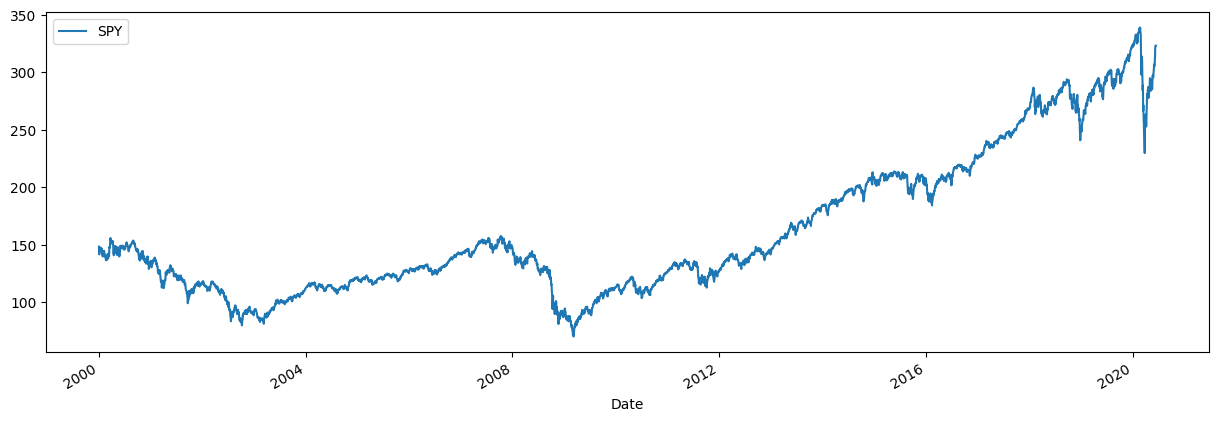

In [4]:
spy = pd.read_csv('SPY.csv', index_col = 'Date', parse_dates = True)
spy['High'].plot(figsize=(15,5), label = 'SPY')
plt.legend(loc = 'upper left')
plt.show()

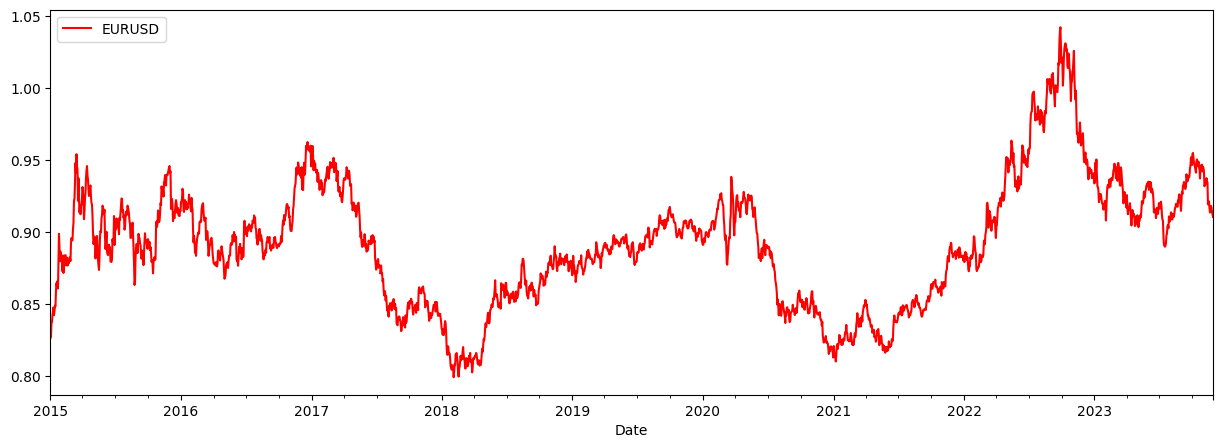

In [5]:
eurusd = pd.read_csv('EURUSD.csv', index_col = 'Date', parse_dates = True)
eurusd['Adj Close'].plot(figsize=(15,5), label = 'EURUSD', color = 'red')
plt.legend(loc = 'upper left')
plt.show()

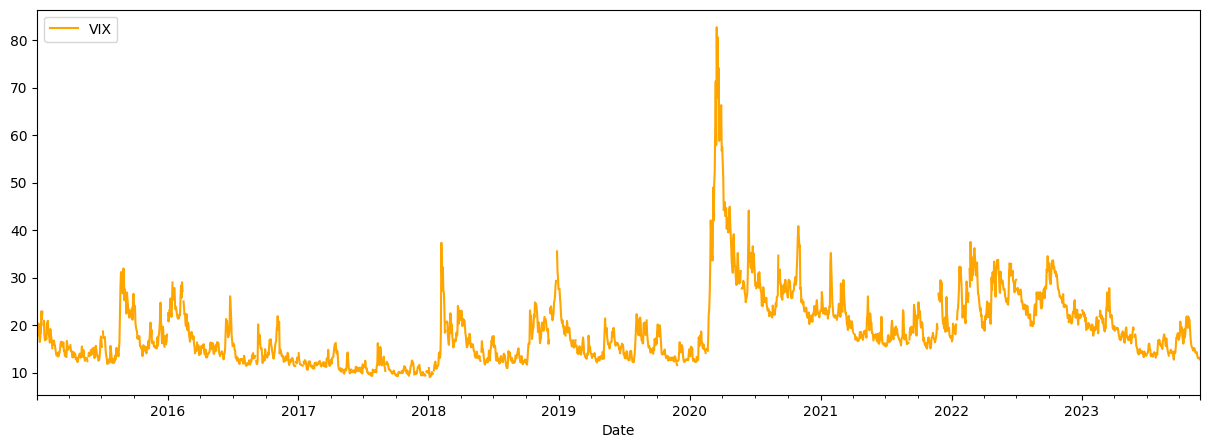

In [6]:
vix = pd.read_csv('VIX.csv', index_col = 'Date', parse_dates = True)
vix['Open'].plot(figsize=(15,5), label = 'VIX', color = 'orange')
plt.legend(loc = 'upper left')
plt.show()

## Actividad 2: Test de Dickey Fuller aumentado

En esta actividad se aplicará el test ADF para testear estacionariedad.
En primer lugar graficaremos la serie de tipo de cambio GBP/USD en el archivo "GBPUSD.csv", correspondiente al período 2009-2014.

¿Tendría argumentos para decir que esta serie sigue un patrón de una serie no estacionaria?

In [7]:
gbpusd = pd.read_csv('GBPUSD.csv', index_col= 'Date', parse_dates = True)
gbpusd.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1566 entries, 2009-01-01 to 2015-01-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1564 non-null   float64
 1   High       1564 non-null   float64
 2   Low        1564 non-null   float64
 3   Close      1564 non-null   float64
 4   Adj Close  1564 non-null   float64
 5   Volume     1564 non-null   float64
dtypes: float64(6)
memory usage: 85.6 KB


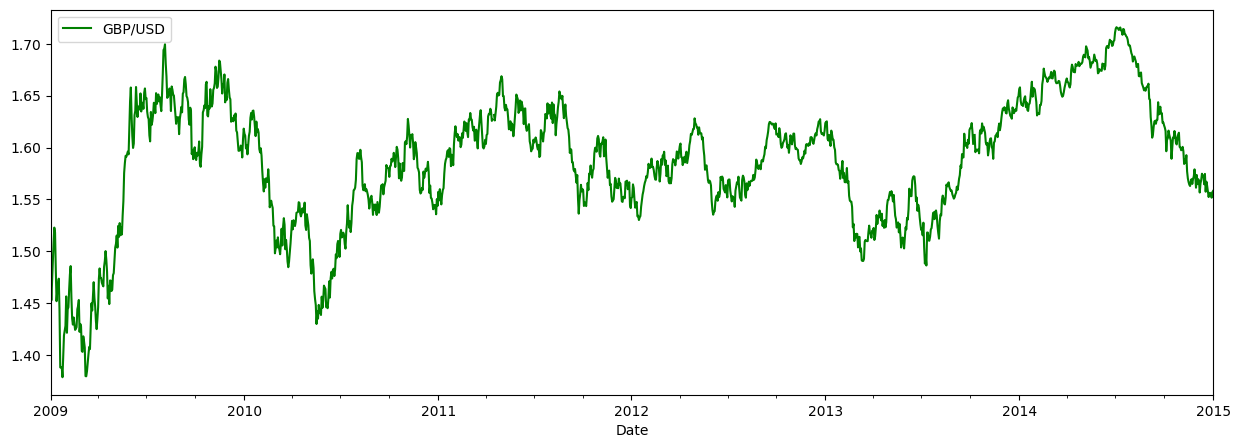

In [8]:
gbpusd["Close"].plot(figsize=(15,5), label = 'GBP/USD', color = 'green')
plt.legend(loc = 'upper left')
plt.show()


Para tener mayor seguridad y posteriormete poder realizar mejores predicciones, aplicaremos el test de Dickey Fuller.

1. Importe la función adfuller() desde statsmodels.
2. Corra la función adfuller() a la columna "Adj Close" del data frame de la serie.
3. Imprima:
    - el valor del estadístico
    - el p-valor
    - los valores críticos.

In [9]:
# Eliminar filas con NaN en la columna "Adj Close"
gbpusd = gbpusd.dropna(subset=['Adj Close'])

In [10]:
# Importar ADF
from statsmodels.tsa.stattools import adfuller

# Correr el test
result = adfuller(gbpusd['Adj Close'])

# Imprimir el valor del estadístico.
print("Valor del estadistico del test de Dickey-Fuller Aumentado:", result[0])

# Imprimir el p-valor
print("p-valor:", result[1])

# Imprimir los valores críticos.
print("Valores Críticos:", result[4])

Valor del estadistico del test de Dickey-Fuller Aumentado: -3.157752041632651
p-valor: 0.022564139272919975
Valores Críticos: {'1%': -3.4345407051300514, '5%': -2.863390943879109, '10%': -2.567755410866859}


Dado que el estadístico de prueba es menor que el valor crítico del 5% (-3.16 < -2.86) y que el p-valor (0.023) es menor que el nivel de significancia del 5%, hay evidencia suficiente para rechazar la hipótesis nula de que los datos no son estacionarios, es decir, los datos son estacionarios.

Aplicaremos ahora el test ADF a cada una de las series visualizadas en la Actividad 1: SPY, EURUSD y VIX, esta vez para la columna de precios ajustados "Adj Close". ¿Qué conclusiones obtiene?

In [11]:
spy = spy.dropna(subset=['Adj Close'])
eurusd = eurusd.dropna(subset=['Adj Close'])
vix = vix.dropna(subset=['Adj Close'])

In [12]:
# Correr el test para SPY
result_spy = adfuller(spy['Adj Close'])

# Imprimir el valor del estadístico.
print("Valor del estadistico del test de Dickey-Fuller Aumentado:", result_spy[0])

# Imprimir el p-valor
print("p-valor:", result_spy[1])

# Imprimir los valores críticos.
print("Valores Críticos:", result_spy[4])

Valor del estadistico del test de Dickey-Fuller Aumentado: 1.2888483365045411
p-valor: 0.9965457612912608
Valores Críticos: {'1%': -3.4316295982872163, '5%': -2.862105446825125, '10%': -2.5670709875579742}


In [13]:
# Correr el test para EUROUSC
result_euro = adfuller(eurusd['Adj Close'])

# Imprimir el valor del estadístico.
print("Valor del estadistico del test de Dickey-Fuller Aumentado:", result_euro[0])

# Imprimir el p-valor
print("p-valor:", result_euro[1])

# Imprimir los valores críticos.
print("Valores Críticos:", result_euro[4])

Valor del estadistico del test de Dickey-Fuller Aumentado: -2.4901260724049825
p-valor: 0.11789527937682964
Valores Críticos: {'1%': -3.433177890191643, '5%': -2.8627893029861404, '10%': -2.567435059780099}


In [14]:
# Correr el test para VIX
result_vix = adfuller(vix['Adj Close'])

# Imprimir el valor del estadístico.
print("Valor del estadistico del test de Dickey-Fuller Aumentado:", result_vix[0])

# Imprimir el p-valor
print("p-valor:", result_vix[1])

# Imprimir los valores críticos.
print("Valores Críticos:", result_vix[4])

Valor del estadistico del test de Dickey-Fuller Aumentado: -4.953587256616707
p-valor: 2.7398494440236052e-05
Valores Críticos: {'1%': -3.4332831704990503, '5%': -2.862835790766408, '10%': -2.5674598111615343}


Tanto para los datos de SPY, como para los datos EURUSD,  como el estadístico de prueba es mayor que el valor crítico del 5% y el p-valor es mucho mayor que el nivel de significancia del 5%, no hay evidencia suficiente para rechazar la hipótesis nula de que los datos no son estacionarios. Es decir, en ambos casos, los datos no son estacionarios.

De la misma manera,  para los datos VIX, de la comparacion de los valores obtenidos del test de Dickens-Fuller, se obtiene que hay evidencia suficiente para rechazar la hipótesis nula de que los datos no son estacionarios. Esto significa que los datos son estacionarios.

Para aquellas series que no tienen evidencia de "no ser estacionarias", aplicaremos la primera diferencia, eliminando los valores NaN. Asignar esta serie diferenciada a "nombre de serie"_diff y volver a correr el test.

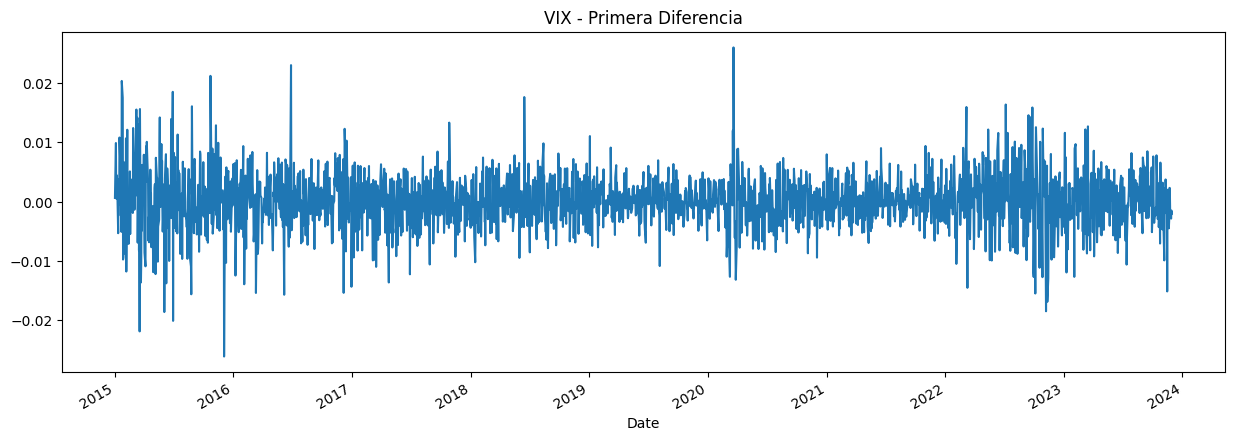

Valor del estadistico del test ADF: -21.167595165757373
p-valor: 0.0


In [15]:
# Calcular la primera diferencia
vix_diff = eurusd.diff()

# Correr el test ADF a la serie diferenciada.
result_diff_vix = adfuller(vix_diff['Adj Close'].dropna())

# Graficar la serie diferenciada
fig, ax = plt.subplots(figsize=(15, 5))
vix_diff['Adj Close'].plot(ax=ax)
plt.title('VIX - Primera Diferencia')
plt.show()

# Imprimir el valor del estadístico y el p-valor de la serie diferenciada.
print('Valor del estadistico del test ADF:', result_diff_vix[0])
print('p-valor:', result_diff_vix[1])

### Otras transformaciones.

Una forma de transformar una serie de precios de acciones es tomando el log-retorno de los precios. Esto se calcula como:

$$\log\left(\frac{P_t}{P_{t-1}}\right)$$

Así por ejemplo, si se trata de la serie de 'AAPL.csv' utilizaremos las funciones:

 $y_t$ <-- data_aapl

 $y_{t-1}$ <--data_aapl.shift(1)

 $log( )$ <-- np.log()

En el siguiente ejercicio le pedimos analizar la existencia de una raíz unitaria para la serie AAPL, y para las transformaciones de log-retorno y las diferencias de primer orden para la serie de AAPL.

In [16]:
## Aplicar el test ADF a la serie.
aapl = pd.read_csv('AAPL.csv', index_col='Date', parse_dates = True)
result_aapl = adfuller(aapl['Adj Close'])
print('Estadístico', result_aapl[0])
print('p-valor', result_aapl[1])

Estadístico 0.9205474043713681
p-valor 0.9933527012638801


Calcular la primera diferencia de la serie temporal para testear estacionariedad.

In [17]:
# Calcular la primera diferencia y eliminar los valores NaN.
aapl_diff = aapl.diff()
aapl_diff = aapl_diff.dropna()

# Correr el test ADF e imprimir.
result_appl_diff = adfuller(aapl_diff['Adj Close'])

# Imprimir el valor del estadístico.
print("Valor del estadistico del test de Dickey-Fuller Aumentado:", result_appl_diff[0])

# Imprimir el p-valor
print("p-valor:", result_appl_diff[1])

# Imprimir los valores críticos.
print("Valores Críticos:", result_appl_diff[4])

Valor del estadistico del test de Dickey-Fuller Aumentado: -13.54716694826398
p-valor: 2.4488284478963035e-25
Valores Críticos: {'1%': -3.432229956544912, '5%': -2.8623706577482046, '10%': -2.5672121737868503}


Estos sugieren que los datos son Estacionarios.

In [18]:
# Calcular los log-retornos y eliminar los NaN.
y_t = aapl['Adj Close']
y_t_1 = aapl['Adj Close'].shift(1)

aapl_log = np.log(y_t / y_t_1)
aapl_log = aapl_log.dropna()

# Correr el test e imprimir.
result_log = adfuller(aapl_log)

# Imprimir el valor del estadístico.
print("Valor del estadistico del test de Dickey-Fuller Aumentado:", result_log[0])

# Imprimir el p-valor
print("p-valor:", result_log[1])

# Imprimir los valores críticos.
print("Valores Críticos:", result_log[4])

Valor del estadistico del test de Dickey-Fuller Aumentado: -12.227077533037235
p-valor: 1.074421159308227e-22
Valores Críticos: {'1%': -3.4322321208787594, '5%': -2.8623716137556454, '10%': -2.567212682738095}


## Actividad 3: Generación de datos ARMA



En esta actividad generaremos datos correspondientes a un modelo AR, MA o ARMA.

Para ello es posible usar la función arma_generate_sample().

Recordar, para cualquier modelo ARMA(p,q):

- La lista de los coeficientes "ar" son de la forma $[1, -a_1, -a_2, ..., -a_p]$.
- La lista de los coeficientes "ma" son de la forma $[1, m_1, m_2, ..., m_q]$,
donde los $a_i$ y $m_j$ son los coeficientes de los retardos $i$ de la parte AR y los retardos $j$ de la parte MA del modelo, respectivamente.

### Modelo MA(1)
Construir un modelo MA(1) que responda a la fórmula:
$$ y_t = a_t - 0.7 a_{t-1}$$
Generar una serie de tiempo con 300 valores.



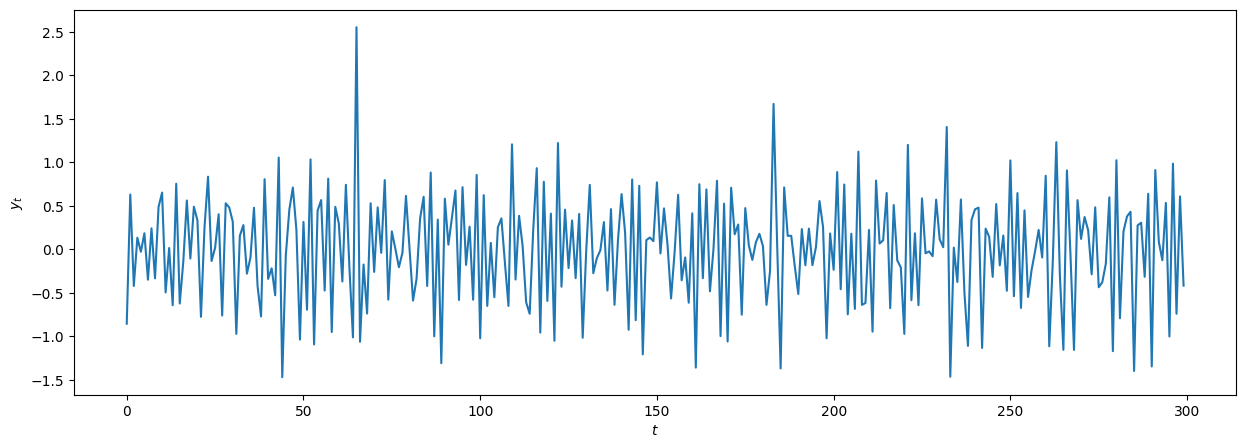

In [19]:
np.random.seed(1)

# Inicializar los coeficientes del modelo MA(1)
ar_coefs = [1]  # No hay parte AR en un modelo MA(1)
ma_coefs = [1, -0.7]  # Coeficiente de la parte MA(1)

# Número de muestras
nsample = 300
# Burn-in para permitir que el proceso alcance la estacionariedad
burn_in = 500

# Generar la serie de tiempo
y = arma_generate_sample(ar_coefs, ma_coefs, nsample=nsample, scale=0.5, burnin=burn_in)

# Ajustar el tamaño de la figura
plt.figure(figsize=(15, 5))

# Graficar la serie de tiempo generada
plt.plot(y)
plt.ylabel(r'$y_t$')
plt.xlabel(r'$t$')
plt.show()

### Modelo AR(1)
Repetir la actividad anterior para el modelo:
$y_t = -0.7y_{t-1} + \epsilon_t $.
Graficarlo.


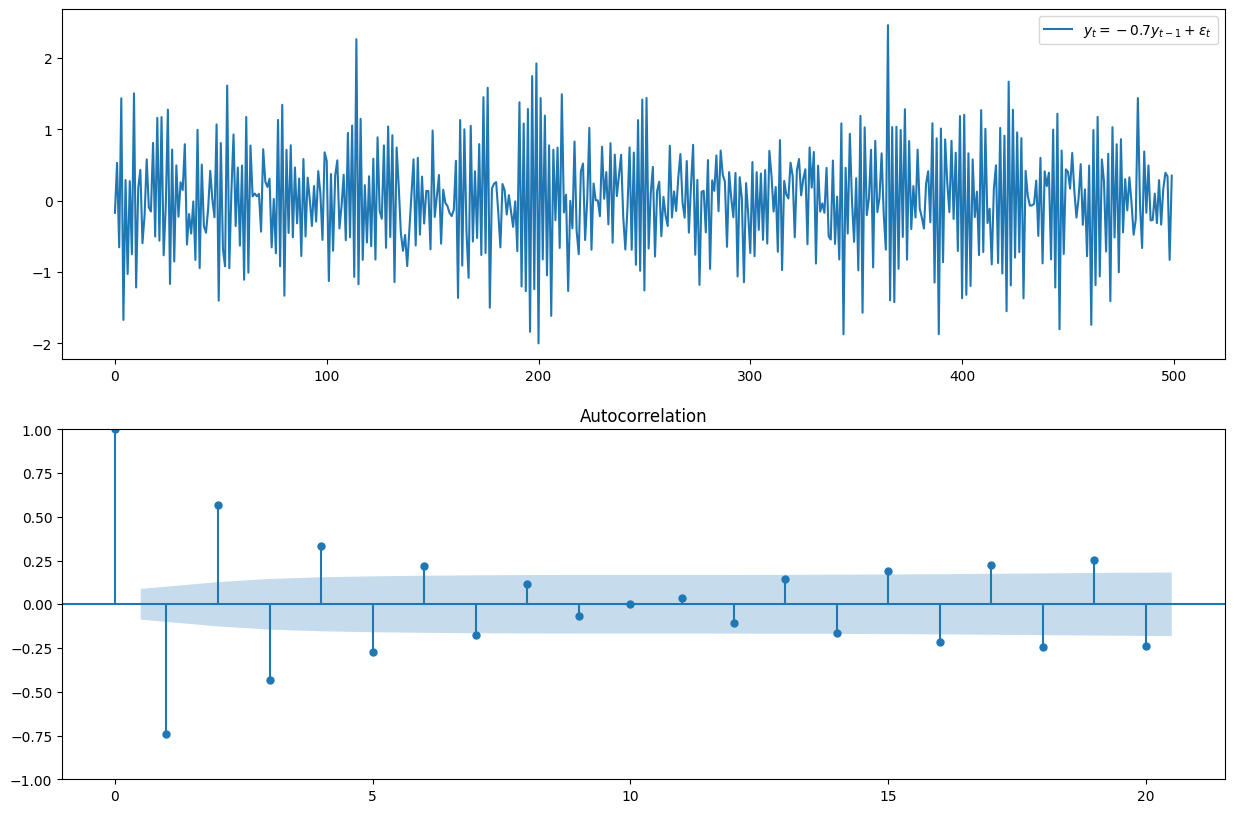

In [20]:
from statsmodels.graphics.tsaplots import plot_acf

# Semilla para reproducibilidad
np.random.seed(1)

# Inicializar los coeficientes del modelo AR(1)
ar_coefs = [1, 0.7]  # Coeficiente autoregresivo para AR(1)
ma_coefs = [1]  # No hay parte MA en este modelo

# Generar la serie de tiempo
y = arma_generate_sample(ar_coefs, ma_coefs, nsample=500, scale=0.5, burnin=200)

# Crear una figura y un eje para la visualización del gráfico con un tamaño específico
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Graficar la serie de tiempo generada
ax[0].plot(y, label=r'$y_t = -0.7 y_{t-1} + \epsilon_t$')
ax[0].legend()

# Graficar la función de autocorrelación
plot_acf(y, lags=20, ax=ax[1])

# Mostrar las gráficas
plt.show()


### Modelo ARMA(p,q)
Repetir la actividad anterior para el modelo:
$y_t = -0.2y_{t-1} + 0.3 a_t + 0.4 a_{t-1}$.
Graficarlo.

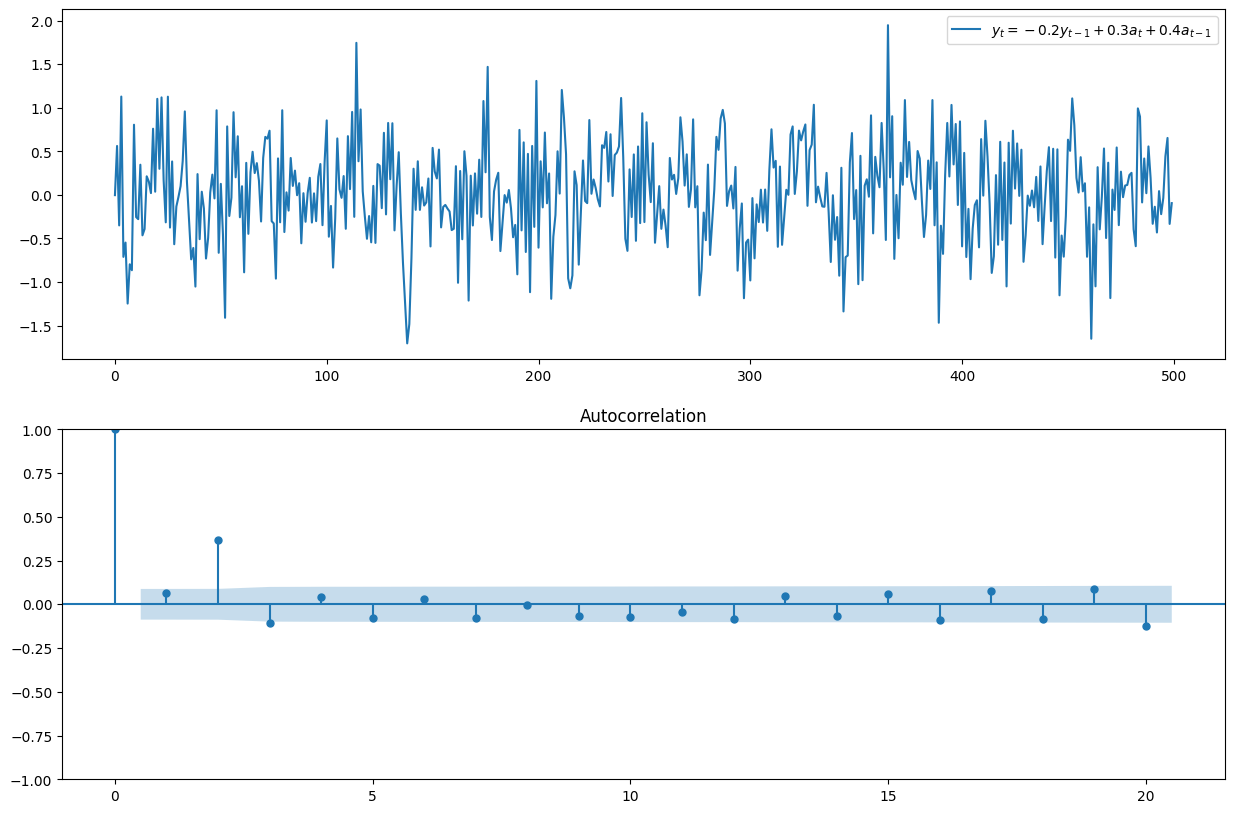

In [22]:
# Semilla para reproducibilidad
np.random.seed(1)

# Inicializar los coeficientes del modelo ARMA(p,q)
ar_coefs = [1, 0.2]  # Coeficientes autoregresivos para AR(1)
ma_coefs = [1, 0.3, 0.4]  # Coeficientes móviles para MA(2)

# Generar la serie de tiempo
y = arma_generate_sample(ar_coefs, ma_coefs, nsample=500, scale=0.5, burnin=200)

# Crear una figura y un eje para la visualización del gráfico con un tamaño específico
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Graficar la serie de tiempo generada
ax[0].plot(y, label=r'$y_t = -0.2y_{t-1} + 0.3 a_t + 0.4 a_{t-1}$')
ax[0].legend()

# Graficar la función de autocorrelación
plot_acf(y, lags=20, ax=ax[1])

# Mostrar las gráficas
plt.show()


##  Ajuste y predicción

En las siguientes celdas crearemos un modelo ARIMA(1,0,1), y luego lo ajustaremos a este modelo.

In [23]:
## Crear un ARMA(1,1)
np.random.seed(1)

# Inicializar los coeficientes del modelo.
ar_coefs = [1, 0.7]
ma_coefs = [1, 0.5]

# Generar la serie.
y = arma_generate_sample(ar_coefs, ma_coefs, nsample=300, scale=0.5, burnin = 500)

In [24]:
#Damos estructura de pandas a la serie.
y = pd.DataFrame(y, columns=['Serie'])

En la siguiente celda, ajustaremos el modelo a un ARIMA(1,0,1).

In [25]:
# Importamos el modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA
# Instanciamos el modelo
model = ARIMA(y, order= (1,0,1))

# Ajustamos el modelo
results = model.fit()

In [26]:
## Imprimimos el resumen estadístico
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Serie   No. Observations:                  300
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -220.252
Date:                Mon, 11 Dec 2023   AIC                            448.503
Time:                        20:14:00   BIC                            463.318
Sample:                             0   HQIC                           454.432
                                - 300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0036      0.025     -0.144      0.886      -0.053       0.045
ar.L1         -0.7858      0.088     -8.884      0.000      -0.959      -0.612
ma.L1          0.5210      0.120      4.348      0.0

Y ahora analizaremos la predicción de nuestro modelo dentro y fuera de la muestra.

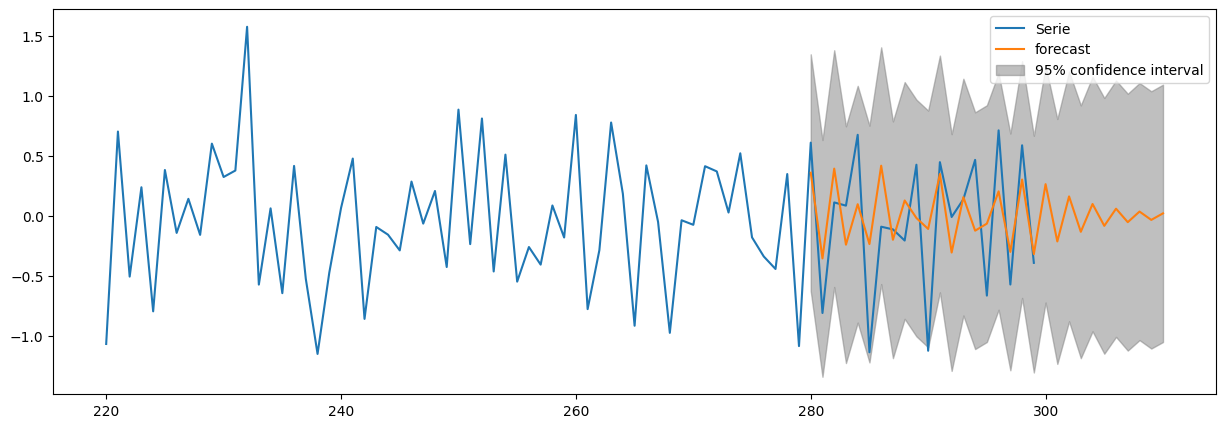

In [27]:
# Importar la función plot_predict desde la biblioteca statsmodels para graficar predicciones en series temporales
from statsmodels.graphics.tsaplots import plot_predict

# Crear una figura y un eje para la visualización del gráfico con un tamaño específico
fig, ax = plt.subplots(figsize=(15, 5))

# Graficar un subconjunto de la serie temporal (iloc[220:300]) en el eje ax
y.iloc[220:300].plot(ax=ax)

# Utilizar la función plot_predict para graficar las predicciones del modelo en el rango de índices 280 a 310 en el mismo eje ax
plot_predict(results, 280, 310, ax=ax)

# Mostrar el gráfico completo con la serie temporal y las predicciones
plt.show()


In [28]:
# Leer datos financieros desde un archivo CSV, utilizando la columna 'Date' como índice y parseando las fechas
spy = pd.read_csv('SPY.csv', index_col='Date', parse_dates=True)

# Calcular los rendimientos logarítmicos diarios
spy_lrets = np.log(spy / spy.shift(1)).dropna()

# Ajustar un modelo ARIMA a los rendimientos logarítmicos con un orden específico (1, 0, 1)
# El orden (1, 0, 1) indica que se está utilizando un componente autorregresivo de orden 1,
# un componente de integración de orden 0, y un componente de media móvil de orden 1.
model_fit = ARIMA(spy_lrets['Adj Close'], order=(1, 0, 1)).fit()

# Imprimir un resumen del ajuste del modelo ARIMA
print(model_fit.summary())


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 5140
Model:                 ARIMA(1, 0, 1)   Log Likelihood               15231.171
Date:                Mon, 11 Dec 2023   AIC                         -30454.341
Time:                        20:14:36   BIC                         -30428.162
Sample:                             0   HQIC                        -30445.178
                               - 5140                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.359      0.174   -9.98e-05       0.001
ar.L1          0.1973      0.052      3.761      0.000       0.094       0.300
ma.L1         -0.2959      0.051     -5.839      0.0

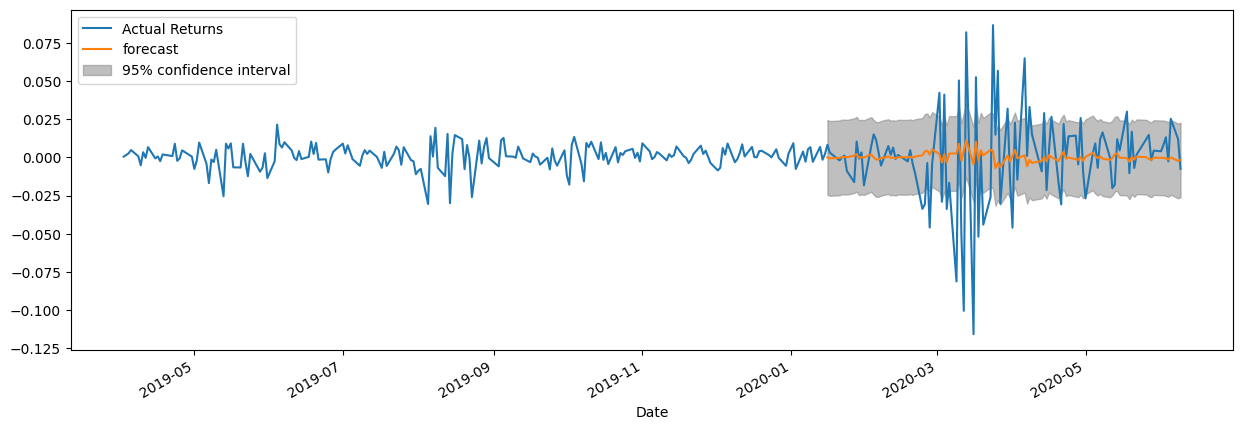

In [29]:
# Crear una figura y un eje para la visualización del gráfico con un tamaño específico
fig, ax = plt.subplots(figsize=(15, 5))

# Graficar los rendimientos logarítmicos diarios de 'Adj Close' para las últimas 300 observaciones en el eje ax
spy_lrets['Adj Close'].iloc[-300:].plot(ax=ax, label='Actual Returns')

# Mostrar la leyenda en la gráfica para identificar las series
plt.legend()

# Utilizar la función plot_predict para graficar las predicciones del modelo desde el último 100 hasta el último índice en el mismo eje ax
# start y end se especifican utilizando los índices de la serie temporal
plot_predict(model_fit, start=spy_lrets.index[-100], end=spy_lrets.index[-1], ax=ax, plot_insample=False)

# Mostrar el gráfico completo con la serie temporal y las predicciones
plt.show()
